In [1]:
"""
Implementação de modelo Random Forest para detecção de fraudes financeiras
Compatível com o pipeline de XGBoost
Dataset: fraudTest.csv
"""

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ============================================
# 1. CARREGAMENTO DOS DADOS
# ============================================

print("=" * 50)
print("1. CARREGANDO DADOS")
print("=" * 50)

df = pd.read_csv("fraudTest.csv")

# Converter target
df["is_fraud"] = df["is_fraud"].replace({-1: 1, 0: 0})

print(df["is_fraud"].value_counts())
print(f"Taxa de fraude: {df['is_fraud'].mean() * 100:.4f}%")


1. CARREGANDO DADOS
is_fraud
0    553574
1      2145
Name: count, dtype: int64
Taxa de fraude: 0.3860%


In [5]:
# ============================================
# 2. ENGENHARIA DE FEATURES
# ============================================

print("\n" + "=" * 50)
print("2. ENGENHARIA DE FEATURES")
print("=" * 50)

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["hora"] = df["trans_date_trans_time"].dt.hour
df["dia_semana"] = df["trans_date_trans_time"].dt.dayofweek
df["dia_mes"] = df["trans_date_trans_time"].dt.day
df["mes"] = df["trans_date_trans_time"].dt.month

df["dob"] = pd.to_datetime(df["dob"])
df["idade"] = (df["trans_date_trans_time"] - df["dob"]).dt.days // 365

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

df["distancia_km"] = haversine_distance(
    df["lat"], df["long"], df["merch_lat"], df["merch_long"]
)

df["amt_log"] = np.log1p(df["amt"])


2. ENGENHARIA DE FEATURES


In [6]:
# ============================================
# 3. SELEÇÃO DE FEATURES
# ============================================

features = [
    "amt", "amt_log", "city_pop", "idade", "distancia_km",
    "hora", "dia_semana", "dia_mes", "mes",
    "category", "gender", "state"
]

X = df[features]
y = df["is_fraud"]


In [7]:
# ============================================
# 4. PRÉ-PROCESSAMENTO
# ============================================

num_features = [
    "amt", "amt_log", "city_pop", "idade", "distancia_km",
    "hora", "dia_semana", "dia_mes", "mes"
]

cat_features = ["category", "gender", "state"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
])

X_processed = preprocessor.fit_transform(X)

In [8]:
# ============================================
# 5. SPLIT TREINO / TESTE
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [9]:
# ============================================
# 6. PESOS DAS CLASSES
# ============================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Pesos das classes: {weight_dict}")

Pesos das classes: {0: np.float64(0.5019367641973461), 1: np.float64(129.58127914723516)}


In [10]:
# ============================================
# 7. TREINAMENTO RANDOM FOREST
# ============================================

print("\n" + "=" * 50)
print("7. TREINANDO RANDOM FOREST")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=weight_dict,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Treinamento concluído!")


7. TREINANDO RANDOM FOREST
Treinamento concluído!


In [11]:
# ============================================
# 8. AVALIAÇÃO DO MODELO
# ============================================

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred, target_names=["Não Fraude", "Fraude"]))

cm = confusion_matrix(y_test, y_pred)
print("\nMATRIZ DE CONFUSÃO:")
print(cm)

roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

print("\nMÉTRICAS:")
print(f"AUC-ROC: {roc_auc:.4f}")
print(f"AUC-PR : {pr_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

  Não Fraude       1.00      1.00      1.00    166072
      Fraude       0.98      0.72      0.83       644

    accuracy                           1.00    166716
   macro avg       0.99      0.86      0.92    166716
weighted avg       1.00      1.00      1.00    166716


MATRIZ DE CONFUSÃO:
[[166061     11]
 [   178    466]]

MÉTRICAS:
AUC-ROC: 0.9943
AUC-PR : 0.9081
Precision: 0.9769
Recall: 0.7236
F1-Score: 0.8314


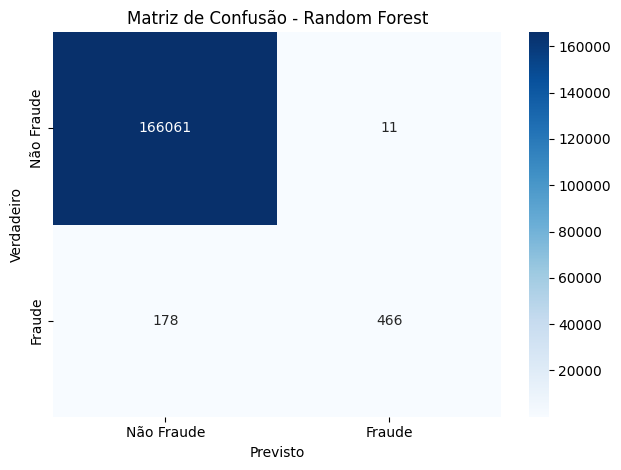

In [12]:
# ============================================
# 9. VISUALIZAÇÕES
# ============================================

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Não Fraude", "Fraude"],
    yticklabels=["Não Fraude", "Fraude"]
)
plt.title("Matriz de Confusão - Random Forest")
plt.ylabel("Verdadeiro")
plt.xlabel("Previsto")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=120)
plt.show()


In [13]:
# ============================================
# 10. SALVAR MODELO
# ============================================

joblib.dump(rf_model, "random_forest_fraud_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("\nModelo salvo:")
print("- random_forest_fraud_model.pkl")
print("- preprocessor.pkl")

print("\n" + "=" * 50)
print("IMPLEMENTAÇÃO RANDOM FOREST CONCLUÍDA!")
print("=" * 50)


Modelo salvo:
- random_forest_fraud_model.pkl
- preprocessor.pkl

IMPLEMENTAÇÃO RANDOM FOREST CONCLUÍDA!
